In [1]:
!pip install numpy scipy

In [2]:
import numpy as np
import scipy as sp
import random
from numpy import pi
import matplotlib.pyplot as plt
%matplotlib inline

# Вариант 6

### Задание

1. Ознакомиться с теоретической частью.

2. На основе лабораторной работы 1, реализовать однородный, КИХ и БИХ фильтр:

    - **однородный**: рекурсивный M=159;
  
    - **КИХ**: полосовой, Ханна, 200-800 Гц M=151;
  
    - **БИХ**: однополюсный НЧ fc=350 Гц;
  
    ---
    
    - рассчитать необходимые для реализации фильтра коэффициенты;
    
    - изменить сигнал из лабораторной работы 1 так, чтобы экспериментально подтвердить правильность работы соответствующего фильтра;
  
    - построить графики;
  
    - сохранить исходный, шумный и фильтрованый сигналы в WAV-файл.

#### Графики
  
- [x] входной функции;

- АЧХ спроектированных фильтров:

    - [ ] однородный
 
    - [x] КИХ

    - [ ] БИХ

- [x] сигнала после внесения искажений;

- [ ] результаты работы однородного фильтра;

- [x] результаты работы КИХ фильтра;

- [ ] результаты работы БИХ фильтра.

In [ ]:
## HELPERS

In [11]:
def plot(y, x, f_name: str|None = None, desc: str|None = None):
    plt.figure(figsize=(4, 3))
    plt.plot(x, y)
    plt.title({
        (True, True): f"{f_name} ({desc})",
        (True, False): f"{f_name}",
        (False, True): f"{desc}",
        (False, False): None,
    }[f_name is not None, desc is not None])
    plt.grid(True)
    plt.show() 
def plot_freqspace(y_fn: Callable, f_s, f_name: str|None = None, desc: str|None = None):
    SAMPLE_COUNT = 512
    x = np.linspace(0, SAMPLE_COUNT / f_s, SAMPLE_COUNT)
    f = np.linspace(0, f_s, SAMPLE_COUNT)
    f = np.fft.fftshift(f) - f_s/2
    
    plot(np.abs(np.fft.fft(y_fn(x))), f, f"FFT[{f_name}]" if f_name is not None else None, desc)

In [3]:
A_x = [1, 0.5, 0.3, 0.1]
f0_x = 262 #Hz
h_x = [1, 2, 4, 8]
phi_x = 0

In [8]:
F = f0_x # base freq
F_S = 2 * 2*F*max(h_x) # optimal sampling freq
SAMPLE_COUNT = 1024

NOISE_HARMONICS = [
    (random.uniform(0.3, 0.9), random.uniform(max(h_x), 2*max(h_x))) # (amplitude, frequency multiplier)
    for i in range(3) # how many
]

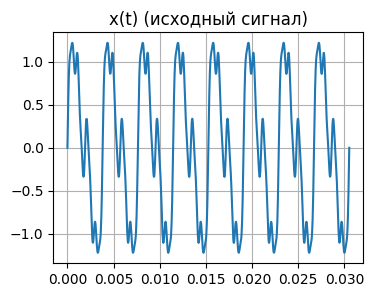

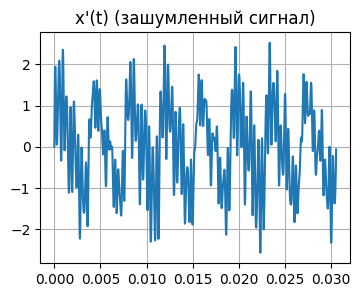

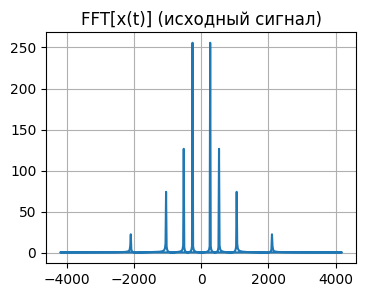

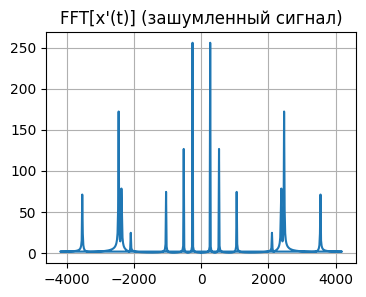

In [30]:
def s(t, A, h, f0, phi):
    assert(len(A) == len(h))
    return sum(
        A[i] * np.sin(2*pi * h[i] * f0 * t + phi)
        for i in range(0, len(A))
    )
x = lambda t: s(t, A_x, h_x, f0_x, phi_x)
x_noisy = lambda t: x(t) + sum([a * np.sin(2*pi * f_mul*F * t) for a, f_mul in NOISE_HARMONICS])

t = np.linspace(0, 8 / F, SAMPLE_COUNT)

plot(x(t), t, "x(t)", "исходный сигнал")
plot(x_noisy(t), t, "x'(t)", "зашумленный сигнал")
plot_freqspace(x, F_S, "x(t)", "исходный сигнал")
plot_freqspace(x_noisy, F_S, "x'(t)", "зашумленный сигнал")

## КИХ

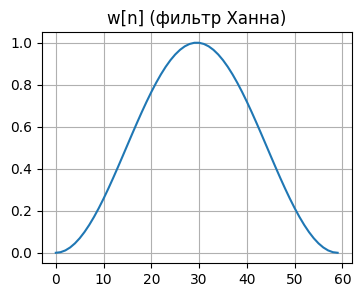

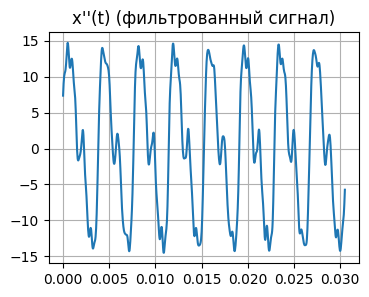

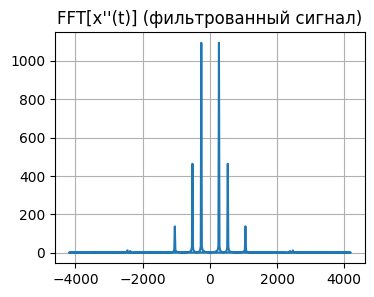

In [37]:
hanning_window = lambda n: 0.5 * (1 - np.cos(2*pi*n/(len(n)-1)))
def hanning(x, n=10): return np.convolve(x, hanning_window(np.linspace(0, n-1, n)), mode="same")

N = 60
n = np.linspace(0, N-1, N)
plot(hanning_window(n), n, "w[n]", "фильтр Ханна")

t = np.linspace(0, 8 / F, SAMPLE_COUNT)
plot(hanning(x_noisy(t), 25), t, "x''(t)", "фильтрованный сигнал")
plot_freqspace(lambda t: hanning(x_noisy(t), 10), F_S, "x''(t)", "фильтрованный сигнал")
